In [1]:
# ENTROPY METRIC

import numpy as np

def compute_entropy(saliency_map):

    saliency_map = saliency_map.astype(np.float32)

    saliency_map = saliency_map / (
        saliency_map.sum() + 1e-8
    )

    entropy = -np.sum(
        saliency_map *
        np.log(
            saliency_map + 1e-8
        )
    )

    return entropy

In [2]:
# INSERTION METRIC

import cv2
import numpy as np
import torch

def insertion_metric(
    model,
    image_tensor,
    saliency_map,
    target_class,
    steps=50,
    device="cpu"
):

    model.eval()

    image = image_tensor.squeeze().cpu().numpy()   # (C,H,W)

    C, H, W = image.shape

    # Saliency ranking from 2D map
    saliency_flat = saliency_map.flatten()

    ranking = np.argsort(
        saliency_flat
    )[::-1]

    # blurred baseline

    baseline = cv2.GaussianBlur(
        image.transpose(1,2,0),
        (31,31),
        0
    )

    baseline = baseline.transpose(2,0,1)

    scores = []

    total_pixels = H * W

    for step in range(steps):

        k = int(
            total_pixels *
            (step + 1) / steps
        )

        modified = baseline.copy()

        selected_pixels = ranking[:k]

        rows = selected_pixels // W
        cols = selected_pixels % W

        # restore all channels
        modified[:, rows, cols] = image[:, rows, cols]

        inp = torch.tensor(
            modified,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            prob = torch.softmax(
                model(inp),
                dim=1
            )[0, target_class]

        scores.append(prob.item())

    auc = np.trapz(scores)

    return auc, scores

In [3]:
# DELETION METRIC

def deletion_metric(
    model,
    image_tensor,
    saliency_map,
    target_class,
    steps=50,
    device="cpu"
):

    model.eval()

    image = image_tensor.squeeze().cpu().numpy()

    C, H, W = image.shape

    saliency_flat = saliency_map.flatten()

    ranking = np.argsort(
        saliency_flat
    )[::-1]

    blurred = cv2.GaussianBlur(
        image.transpose(1,2,0),
        (31,31),
        0
    )

    blurred = blurred.transpose(2,0,1)

    scores = []

    total_pixels = H * W

    for step in range(steps):

        k = int(
            total_pixels *
            (step + 1) / steps
        )

        modified = image.copy()

        selected_pixels = ranking[:k]

        rows = selected_pixels // W
        cols = selected_pixels % W

        # delete all channels
        modified[:, rows, cols] = blurred[:, rows, cols]

        inp = torch.tensor(
            modified,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            prob = torch.softmax(
                model(inp),
                dim=1
            )[0, target_class]

        scores.append(prob.item())

    # Normalizing to cater for the different possible values of steps in each epoch
    auc = np.trapz(scores) / len(scores)
    
    return auc, scores

In [4]:
# AREA OVER PERTURBATION CURVE (AOPC) METRIC

def compute_aopc(
    model,
    image_tensor,
    saliency_map,
    target_class,
    steps=50,
    device="cpu"
):

    model.eval()

    with torch.no_grad():

        original_score = torch.softmax(
            model(image_tensor.to(device)),
            dim=1
        )[0,target_class].item()

    image = image_tensor.squeeze().cpu().numpy()

    saliency = saliency_map.flatten()

    order = np.argsort(
        saliency
    )[::-1]

    total_pixels = len(order)

    score_drop = []

    for i in range(steps):

        k = int(
            total_pixels *
            (i+1)/steps
        )

        modified = image.copy()

        idx = order[:k]

        modified.reshape(-1)[idx] = 0

        inp = torch.tensor(
            modified,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            score = torch.softmax(
                model(inp),
                dim=1
            )[0,target_class].item()

        score_drop.append(
            original_score - score
        )

    return np.mean(score_drop)

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms, models

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

ORG_IMG_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/Random_100_cropped"
SALIENCY_MAP_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/2/Att_Roll_Basic_ViT/Saliency_maps"
image_paths = os.listdir(ORG_IMG_DIR)

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    rgb_img = np.array(
        img.resize((224,224))
    ) / 255.0
    return tensor, rgb_img


In [11]:
# Basic CNN MODEL

class ChestCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(

            # BLOCK 1
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # BLOCK 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # BLOCK 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = ChestCNN(
    num_classes=3
)

OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Basic_CNN_baseline/Outputs/2"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_cnn.pth")
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)
model.to(DEVICE)
model.eval()


ChestCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
## CheXNet model
model = models.densenet121()
model.classifier = nn.Linear(
    model.classifier.in_features,
    3
)

OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/CheXNet_baseline/Outputs/2"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_chexnet.pth")
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)
model.to(DEVICE)
model.eval()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [65]:
# ViT model
# ViT MODEL
model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=3
)

OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/ViT_baseline/Outputs/2"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_vit.pth")
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropou

In [ ]:
# Hybrid MODEL: CNN + TRANSFORMER

class CNNTransformerHybrid(nn.Module):
    def __init__(
        self,
        num_classes=3,
        embed_dim=256,
        num_heads=8,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        # Pretrained CNN stem (DenseNet121)
        backbone = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )
        self.cnn = backbone.features  # output: [B, 1024, H, W]

        # Project CNN channels into transformer embedding dimension
        self.proj = nn.Conv2d(1024, embed_dim, kernel_size=1)

        # For 224x224 inputs with DenseNet121 features, output is typically 7x7
        # -> 49 tokens + 1 CLS token
        self.num_tokens = 49
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.cnn(x)              # [B, 1024, 7, 7]
        x = F.relu(x, inplace=True)
        x = self.proj(x)             # [B, embed_dim, 7, 7]

        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, 49, embed_dim]

        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)          # [B, 50, embed_dim]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer(x)
        x = self.norm(x[:, 0])       # CLS token
        x = self.head(x)
        return x

model = CNNTransformerHybrid(num_classes=NUM_CLASSES).to(DEVICE)

OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Hybrid_baseline/Outputs/2"
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_hybrid_cnn_transformer.pth")
model.load_state_dict(torch.load(BEST_MODEL_DIR, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()


In [16]:
all_entropy = []
all_insertion = []
all_ins_scores = []
all_deletion = []
all_del_scores = []
all_aopc = []

for i in image_paths:
    image_tensor, rgb_img = load_image(
        os.path.join(ORG_IMG_DIR, i)
    )
    image_tensor = image_tensor.to(DEVICE)

    # Generate explanation
    saliency_map = np.load(os.path.join(SALIENCY_MAP_DIR, f"{os.path.splitext(i)[0]}.npy"))

    # Prediction
    with torch.no_grad():
        pred_class = model(
            image_tensor
        ).argmax(1).item()
    
    ent = compute_entropy(
        saliency_map
    )
    ins_auc, ins_score = insertion_metric(
        model,
        image_tensor,
        saliency_map,
        pred_class
    )
    del_auc, del_score = deletion_metric(
        model,
        image_tensor,
        saliency_map,
        pred_class
    )
    aopc = compute_aopc(
        model,
        image_tensor,
        saliency_map,
        pred_class
    )
    
    all_entropy.append(ent)
    all_insertion.append(ins_auc)
    all_ins_scores.append(ins_score)
    all_deletion.append(del_auc)
    all_del_scores.append(del_score)
    all_aopc.append(aopc)

print("Entropy:",
      np.mean(all_entropy))
print("Insertion:",
      np.mean(all_insertion))
print("Deletion:",
      np.mean(all_deletion))
print("AOPC:",
      np.mean(all_aopc))


/var/folders/dh/3f_yt29x3ts2265xcpl29q_80000gn/T/ipykernel_14515/2256791856.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(scores)
/var/folders/dh/3f_yt29x3ts2265xcpl29q_80000gn/T/ipykernel_14515/700251251.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(scores) / len(scores)


Entropy: 10.213839
Insertion: 35.18756578659086
Deletion: 0.6220298546261707
AOPC: 0.5790817437507051


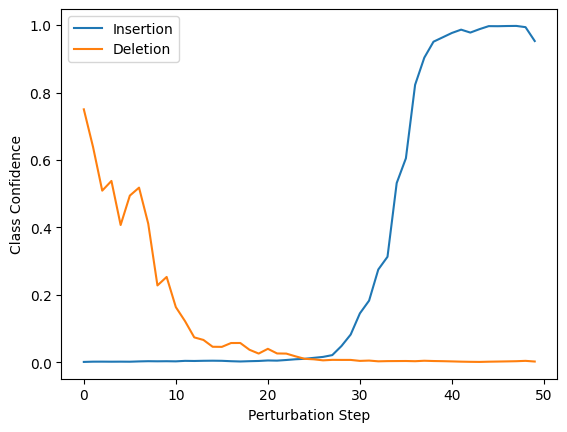

In [17]:
plt.plot(all_ins_scores[17], label="Insertion")
plt.plot(all_del_scores[17], label="Deletion")
plt.xlabel("Perturbation Step")
plt.ylabel("Class Confidence")
plt.legend()
plt.show()
# plt.savefig(save_fig_path, dpi = 300)
